In [1]:
!pip install diffusers transformers gradio accelerate -q

In [2]:
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt
import torch

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [3]:
!pip show torch

Name: torch
Version: 2.9.0+cu126
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License: BSD-3-Clause
Location: /usr/local/lib/python3.12/dist-packages
Requires: filelock, fsspec, jinja2, networkx, nvidia-cublas-cu12, nvidia-cuda-cupti-cu12, nvidia-cuda-nvrtc-cu12, nvidia-cuda-runtime-cu12, nvidia-cudnn-cu12, nvidia-cufft-cu12, nvidia-cufile-cu12, nvidia-curand-cu12, nvidia-cusolver-cu12, nvidia-cusparse-cu12, nvidia-cusparselt-cu12, nvidia-nccl-cu12, nvidia-nvjitlink-cu12, nvidia-nvshmem-cu12, nvidia-nvtx-cu12, setuptools, sympy, triton, typing-extensions
Required-by: accelerate, fastai, peft, sentence-transformers, timm, torchaudio, torchdata, torchvision


In [4]:
model_id1 = "dreamlike-art/dreamlike-diffusion-1.0"
model_id2 = "stabilityai/stable-diffusion-xl-base-1.0"

device = "cuda" if torch.cuda.is_available() else "cpu"
d_type = torch.float16 if device == "cuda" else torch.float32
pipe = StableDiffusionPipeline.from_pretrained(model_id1, torch_dtype = d_type, use_safetensor = True)
pipe = pipe.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/511 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

scheduler_config.json:   0%|          | 0.00/341 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/807 [00:00<?, ?B/s]

...

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.72G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

Keyword arguments {'use_safetensor': True} are not expected by StableDiffusionPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


In [5]:
prompt = """dreamlike, a grungy women with rainbow hair, travelling between dimensions, dynamic pose, happy, soft eyes and narrow chin,
extreme bokeh, dainty figure, long hair, straight down, town kawaii shirt and baggy jeans"""

In [6]:
image = pipe(prompt).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

[PROMPT]:  dreamlike, a grungy women with rainbow hair, travelling between dimensions, dynamic pose, happy, soft eyes and narrow chin,
extreme bokeh, dainty figure, long hair, straight down, town kawaii shirt and baggy jeans


(np.float64(-0.5), np.float64(639.5), np.float64(639.5), np.float64(-0.5))

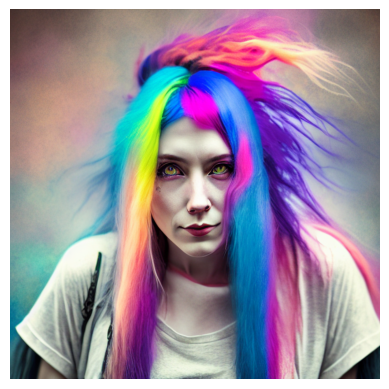

In [7]:
print("[PROMPT]: ", prompt)
plt.imshow(image)
plt.axis('off')

In [8]:
prompt2 = """A girl is sitting on a chair and she is accompanied by her tiger. Make sure it looks cinematic and color of her iris is golden"""
image = pipe(prompt2).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

[PROMPT]:  dreamlike, a grungy women with rainbow hair, travelling between dimensions, dynamic pose, happy, soft eyes and narrow chin,
extreme bokeh, dainty figure, long hair, straight down, town kawaii shirt and baggy jeans


(np.float64(-0.5), np.float64(639.5), np.float64(639.5), np.float64(-0.5))

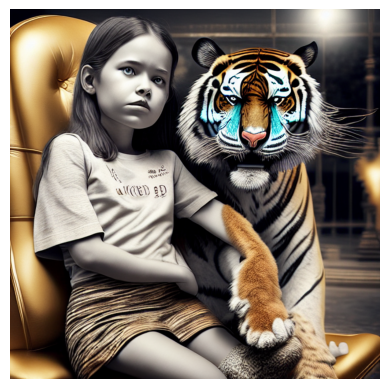

In [9]:
print("[PROMPT]: ", prompt)
plt.imshow(image)
plt.axis('off')

## Working with Stable Diffusion parameters

* num_inference_steps
* height
* weight
* num_images_per_prompt

In [10]:
def generate_image(pipe, prompt, params):
  img = pipe(prompt, **params).images

  num_images = len(img)
  if num_images > 1:
    fig, ax = plt.subplots(nrows = 1, ncols = num_images)
    for i in range(num_images):
      ax[i].imshow(img[i])
      ax[i].axis('off')

  else:
    fig = plt.figure()
    plt.imshow(img[0])
    plt.axis('off')
  plt.tight_layout()

In [11]:
prompt = "dreamlike, beautiful girl playing the festival of colors, draped in traditional mongoli attire, throwing colors everywhere"

  0%|          | 0/100 [00:00<?, ?it/s]

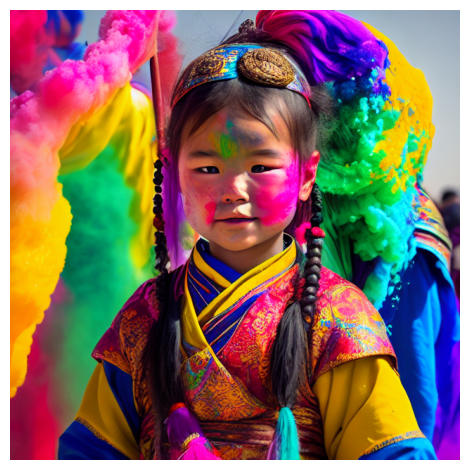

In [12]:
# num inference steps
params = {'num_inference_steps': 100}
generate_image(pipe, prompt, params)

  0%|          | 0/100 [00:00<?, ?it/s]

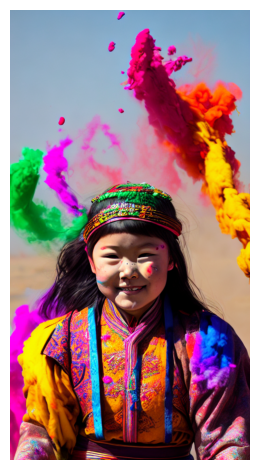

In [13]:
# height weight
params = {
    'num_inference_steps': 100,
    'height': int(1.5*640),
    'width': 512
    }
generate_image(pipe, prompt, params)

  0%|          | 0/100 [00:00<?, ?it/s]

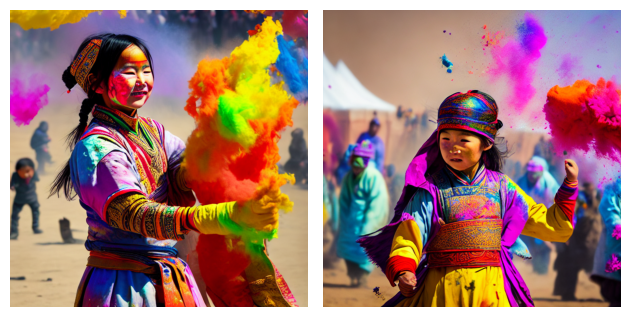

In [14]:
# num_images_per_prompt
params = {'num_inference_steps': 100, 'num_images_per_prompt': 2}
generate_image(pipe, prompt, params)

  0%|          | 0/100 [00:00<?, ?it/s]

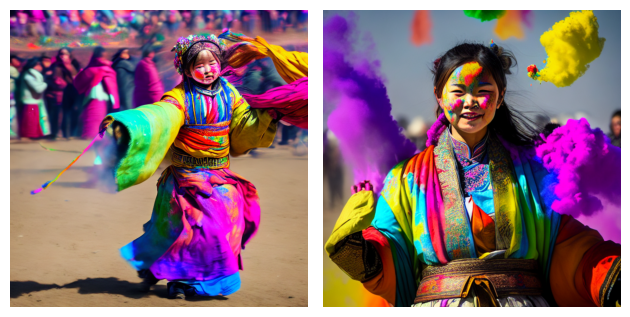

In [15]:
# negative_prompt
params = {
    'num_inference_steps': 100,
    'num_images_per_prompt': 2,
    'nagative_prompt': 'ugly, distorted, low quality'
    }
generate_image(pipe, prompt, params)